Mobile Banking Barrier Classification

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/content/mobile_banking_dataset.csv')
display(df.head())

,Perceived_Ease_of_Use,Internet_Access,Peer_Influence,Financial_Status,Prior_Experience,Privacy_Concern,Family_Norms,Barrier_Label
0,3,3,4,1,4,2,2,Psychological
1,2,3,3,3,2,2,3,Technological
2,2,2,4,3,2,4,2,Technological
3,3,2,1,4,3,3,2,Social
4,3,3,4,1,3,3,3,Financial


In [4]:
df.shape

(200, 8)

In [5]:
df.isna().sum()

,0
Perceived_Ease_of_Use,0
Internet_Access,0
Peer_Influence,0
Financial_Status,0
Prior_Experience,0
Privacy_Concern,0
Family_Norms,0
Barrier_Label,0


In [6]:
df['Barrier_Label'].value_counts()

,count
Barrier_Label,
Psychological,50
Technological,50
Social,50
Financial,50


In [7]:
num_col = df.select_dtypes(include=['int64']).columns.tolist()
num_col

['Perceived_Ease_of_Use',
 'Internet_Access',
 'Peer_Influence',
 'Financial_Status',
 'Prior_Experience',
 'Privacy_Concern',
 'Family_Norms']

In [8]:
obj_col = df.select_dtypes(include=['object']).columns.tolist()
obj_col

['Barrier_Label']

### Data Preprocessing

In [9]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, f1_score, recall_score

In [10]:
le = LabelEncoder()
df['Label_Encoded'] = le.fit_transform(df['Barrier_Label'])
print(le.classes_)

['Financial' 'Psychological' 'Social' 'Technological']


In [11]:
FEATURES = ['Perceived_Ease_of_Use', 'Internet_Access', 'Peer_Influence',
            'Financial_Status', 'Prior_Experience', 'Privacy_Concern', 'Family_Norms']

Y = df['Label_Encoded']
X = df[FEATURES]

In [12]:
Y.head()

,Label_Encoded
0,1
1,3
2,3
3,2
4,0


### Model Training


In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Y_test shape: {Y_test.shape}")

X_train shape: (160, 7)
X_test shape: (40, 7)
Y_train shape: (160,)
Y_test shape: (40,)


In [14]:
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Features scaled successfully.")

Features scaled successfully.


In [15]:
from scipy import stats

z = np.abs(stats.zscore(X_train_scaled))
mask = (z < 3).all(axis=1)
X_train_scaled = X_train_scaled[mask]
Y_train = Y_train.values[mask]
print(f"Samples after outlier removal: {len(X_train_scaled)}")

Samples after outlier removal: 160


Logistic Regression Model

In [16]:
logistic_model = LogisticRegression(max_iter=1000, random_state=42)
logistic_model.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [18]:
Y_Pred_lr = logistic_model.predict(X_test_scaled)
acc_lr  = accuracy_score(Y_test, Y_Pred_lr)
prec_lr = precision_score(Y_test, Y_Pred_lr, average='weighted', zero_division=0)
f1_lr   = f1_score(Y_test, Y_Pred_lr, average='weighted', zero_division=0)
rec_lr  = recall_score(Y_test, Y_Pred_lr, average='weighted', zero_division=0)

In [19]:
print(round(acc_lr * 100, 2))
print(round(prec_lr * 100, 2))
print(round(f1_lr * 100, 2))
print(round(rec_lr * 100, 2))

85.0
85.14
84.74
85.0


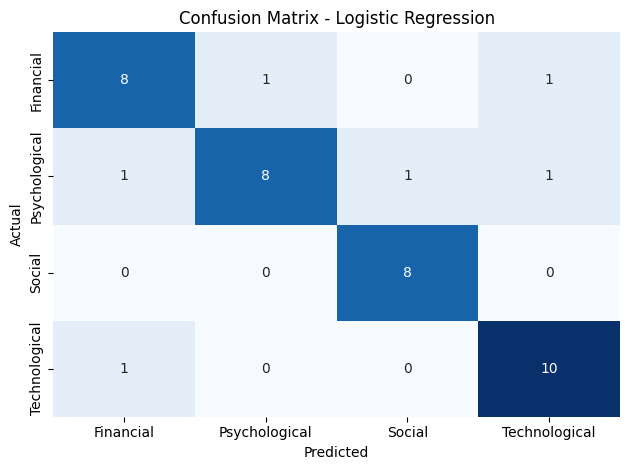

In [20]:
cm_lr = confusion_matrix(Y_test, Y_Pred_lr)
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.savefig('fig2_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

In [22]:
print(classification_report(Y_test, Y_Pred_lr, target_names=le.classes_))

               precision    recall  f1-score   support

    Financial       0.80      0.80      0.80        10
Psychological       0.89      0.73      0.80        11
       Social       0.89      1.00      0.94         8
Technological       0.83      0.91      0.87        11

     accuracy                           0.85        40
    macro avg       0.85      0.86      0.85        40
 weighted avg       0.85      0.85      0.85        40



Decision Tree Model

In [23]:
dec_tree_model = DecisionTreeClassifier(criterion='gini', max_depth=4,
                                        min_samples_split=10, min_samples_leaf=5,
                                        random_state=42)
dec_tree_model.fit(X_train_scaled, Y_train)

DecisionTreeClassifier(max_depth=4, min_samples_leaf=5, min_samples_split=10,
                       random_state=42)

In [24]:
x_pred_dt = dec_tree_model.predict(X_test_scaled)
acc_dt  = accuracy_score(Y_test, x_pred_dt)
prec_dt = precision_score(Y_test, x_pred_dt, average='weighted', zero_division=0)
f1_dt   = f1_score(Y_test, x_pred_dt, average='weighted', zero_division=0)
rec_dt  = recall_score(Y_test, x_pred_dt, average='weighted', zero_division=0)

In [25]:
print(round(acc_dt * 100, 2))
print(round(prec_dt * 100, 2))
print(round(f1_dt * 100, 2))
print(round(rec_dt * 100, 2))

60.0
63.79
59.27
60.0


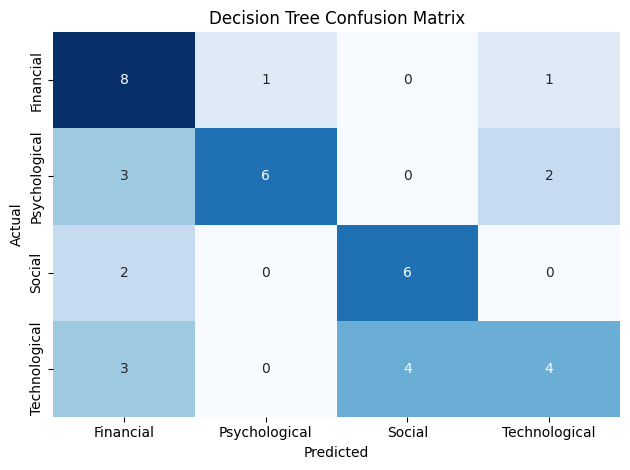

In [26]:
cm_dt = confusion_matrix(Y_test, x_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.savefig('fig3_confusion_matrix_dt.png', dpi=150, bbox_inches='tight')
plt.show()

In [27]:
print(classification_report(Y_test, x_pred_dt, target_names=le.classes_))

               precision    recall  f1-score   support

    Financial       0.50      0.80      0.62        10
Psychological       0.86      0.55      0.67        11
       Social       0.60      0.75      0.67         8
Technological       0.57      0.36      0.44        11

     accuracy                           0.60        40
    macro avg       0.63      0.61      0.60        40
 weighted avg       0.64      0.60      0.59        40



### Results and Figures

In [28]:
baseline_model = DummyClassifier(strategy='most_frequent', random_state=42)
baseline_model.fit(X_train_scaled, Y_train)
y_pred_base = baseline_model.predict(X_test_scaled)
acc_base  = accuracy_score(Y_test, y_pred_base) * 100
prec_base = precision_score(Y_test, y_pred_base, average='weighted', zero_division=0) * 100
rec_base  = recall_score(Y_test, y_pred_base, average='weighted', zero_division=0) * 100
f1_base   = f1_score(Y_test, y_pred_base, average='weighted', zero_division=0) * 100
print("Baseline trained.")

Baseline trained.


In [29]:
results = {
    'Model':     ['Baseline', 'Logistic Regression', 'Decision Tree'],
    'Accuracy':  [round(acc_base, 2),      round(acc_lr*100, 2),  round(acc_dt*100, 2)],
    'Precision': [round(prec_base, 2),     round(prec_lr*100, 2), round(prec_dt*100, 2)],
    'Recall':    [round(rec_base, 2),      round(rec_lr*100, 2),  round(rec_dt*100, 2)],
    'F1_Score':  [round(f1_base, 2),       round(f1_lr*100, 2),   round(f1_dt*100, 2)],
}
results_df = pd.DataFrame(results).set_index('Model')
print(results_df)

                     Accuracy  Precision  Recall  F1_Score
Model                                                     
Baseline                 20.0       4.00    20.0      6.67
Logistic Regression      85.0      85.14    85.0     84.74
Decision Tree            60.0      63.79    60.0     59.27


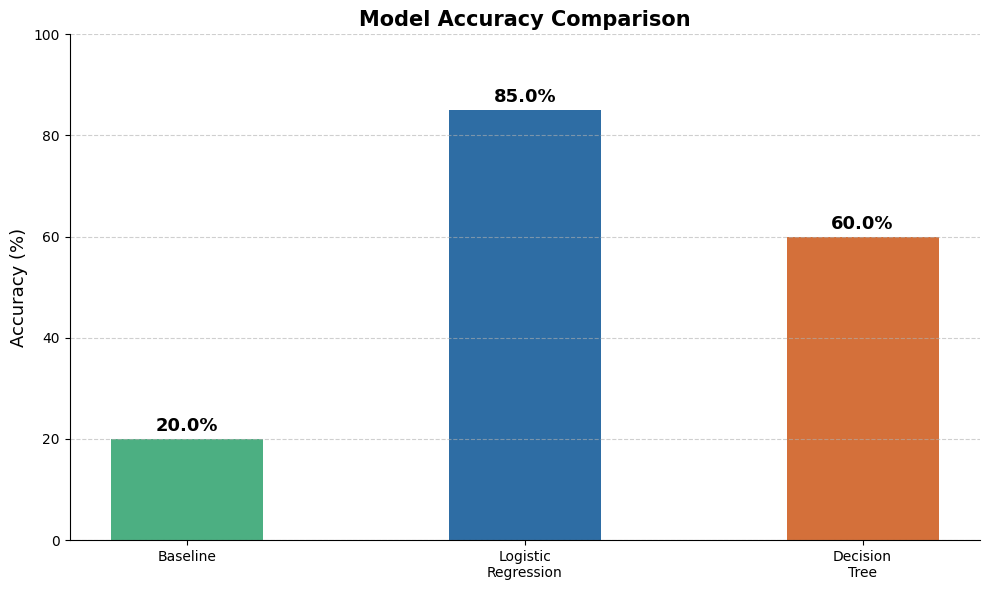

In [30]:
models     = ['Baseline', 'Logistic\nRegression', 'Decision\nTree']
accuracies = [acc_base, acc_lr*100, acc_dt*100]
colors     = ['#4CAF82', '#2E6DA4', '#D4703A']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models, accuracies, color=colors, width=0.45, edgecolor='none')
for bar, val in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.8,
            f'{val:.1f}%', ha='center', va='bottom',
            fontsize=13, fontweight='bold')
ax.set_ylim(0, 100)
ax.set_ylabel('Accuracy (%)', fontsize=13)
ax.set_title('Model Accuracy Comparison', fontsize=15, fontweight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig1_accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

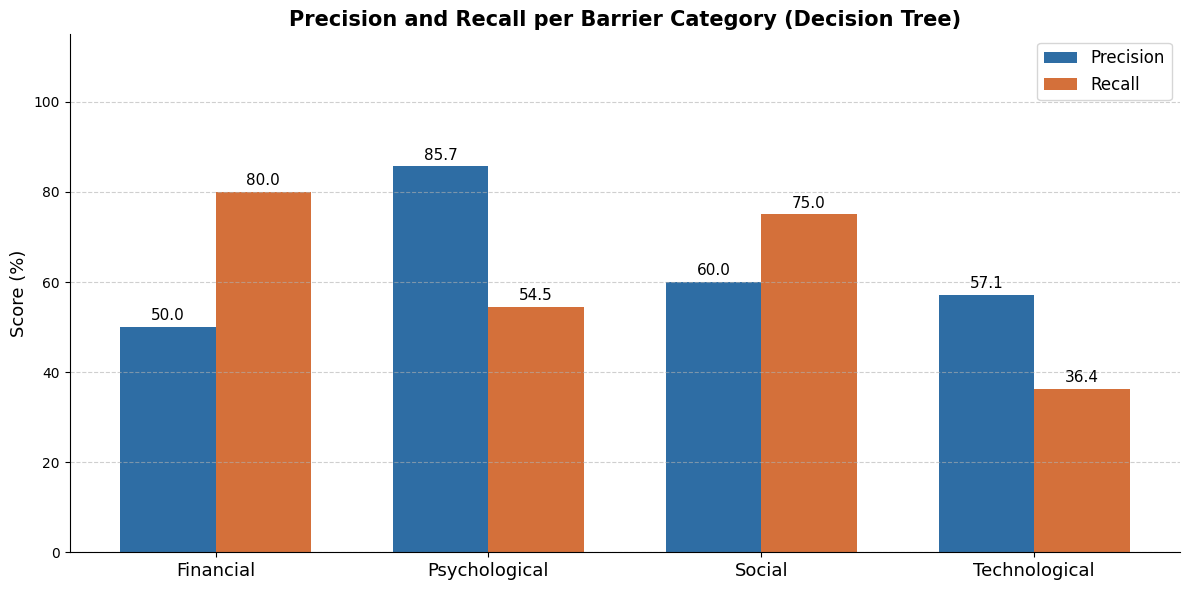

In [31]:
prec_per = precision_score(Y_test, x_pred_dt, average=None, zero_division=0) * 100
rec_per  = recall_score(Y_test, x_pred_dt,    average=None, zero_division=0) * 100
x        = np.arange(len(le.classes_))
width    = 0.35

fig, ax = plt.subplots(figsize=(12, 6))
bp = ax.bar(x - width/2, prec_per, width, color='#2E6DA4', label='Precision', edgecolor='none')
br = ax.bar(x + width/2, rec_per,  width, color='#D4703A', label='Recall',    edgecolor='none')
for bar, val in zip(bp, prec_per):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11)
for bar, val in zip(br, rec_per):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.8,
            f'{val:.1f}', ha='center', va='bottom', fontsize=11)
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Precision and Recall per Barrier Category (Decision Tree)', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(le.classes_, fontsize=13)
ax.legend(fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig4_precision_recall.png', dpi=150, bbox_inches='tight')
plt.show()

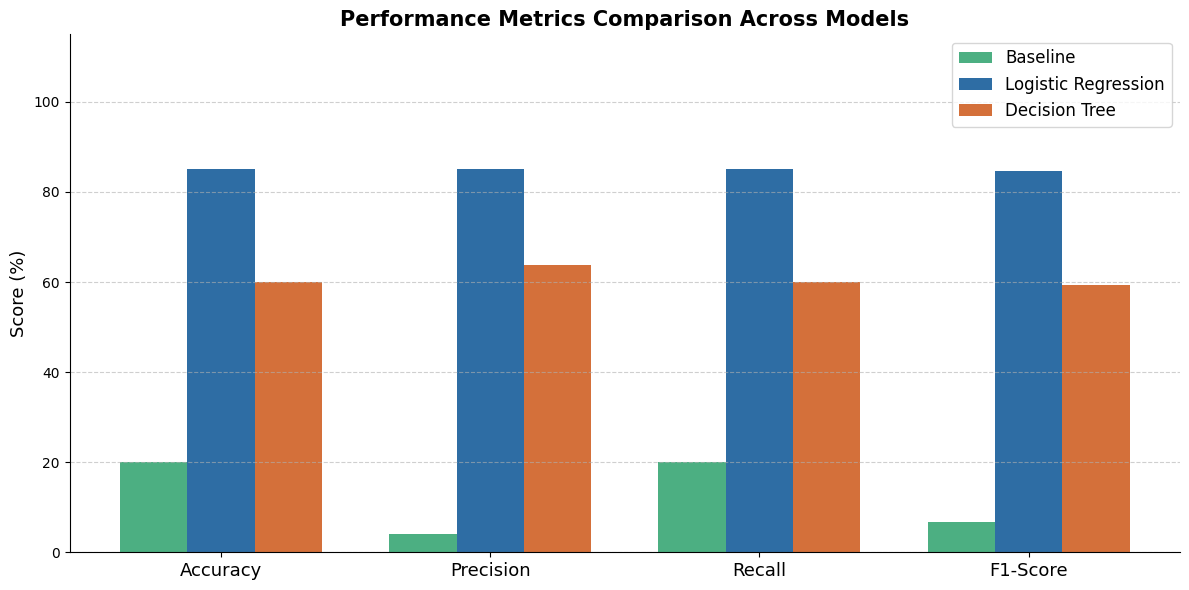

In [32]:
metric_cols  = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
metric_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
bv = [results_df.loc['Baseline',            c] for c in metric_cols]
lv = [results_df.loc['Logistic Regression', c] for c in metric_cols]
dv = [results_df.loc['Decision Tree',       c] for c in metric_cols]
x, w = np.arange(4), 0.25

fig, ax = plt.subplots(figsize=(12, 6))
ax.bar(x-w,   bv, w, color='#4CAF82', label='Baseline',            edgecolor='none')
ax.bar(x,     lv, w, color='#2E6DA4', label='Logistic Regression', edgecolor='none')
ax.bar(x+w,   dv, w, color='#D4703A', label='Decision Tree',       edgecolor='none')
ax.set_ylim(0, 115)
ax.set_ylabel('Score (%)', fontsize=13)
ax.set_title('Performance Metrics Comparison Across Models', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(metric_names, fontsize=13)
ax.legend(fontsize=12, loc='upper right')
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.grid(axis='x', visible=False)
plt.tight_layout()
plt.savefig('fig5_metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

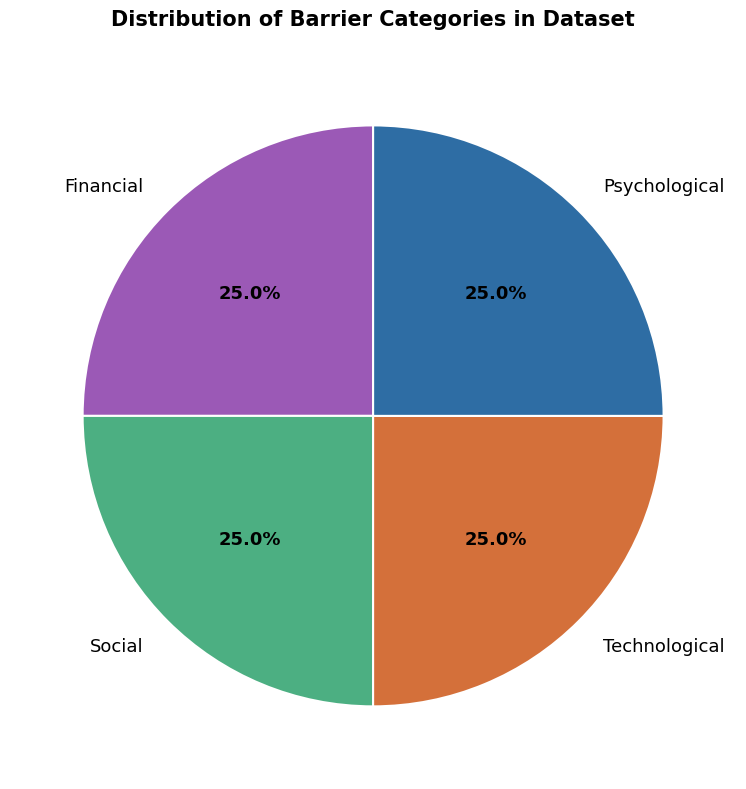

In [33]:
counts     = df['Barrier_Label'].value_counts()
pie_order  = ['Financial', 'Social', 'Technological', 'Psychological']
pie_sizes  = [counts[l] for l in pie_order]
pie_colors = ['#9B59B6', '#4CAF82', '#D4703A', '#2E6DA4']

fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(
    pie_sizes, labels=pie_order, colors=pie_colors,
    autopct='%1.1f%%', startangle=90,
    pctdistance=0.6, labeldistance=1.12,
    wedgeprops={'linewidth': 1.5, 'edgecolor': 'white'})
for t in texts:     t.set_fontsize(13)
for t in autotexts: t.set_fontsize(13); t.set_fontweight('bold')
ax.set_title('Distribution of Barrier Categories in Dataset',
             fontsize=15, fontweight='bold', pad=20)
plt.tight_layout()
plt.savefig('fig6_barrier_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [37]:
from google.colab import files
for f in ['fig1_accuracy_comparison.png',
          'fig2_confusion_matrix.png',
          'fig3_confusion_matrix_dt.png',
          'fig4_precision_recall.png',
          'fig5_metrics_comparison.png',
          'fig6_barrier_distribution.png',]
    files.download(f)
    print(f"Downloaded: {f}")

SyntaxError: '[' was never closed (506173317.py, line 2)